In [1]:
import pandas as pd
import xarray as xr
import rasterio as rio
import numpy as np
import rioxarray
from glob import glob
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
md_df = pd.read_csv('md_processing_decisions.csv').iloc[:, 0:9]
md_df['survey_name'] = md_df['survey_name'].str.strip()

rolpa
barun
imja
lumding
chamlang_south
thugali
nagma
chamlang_north
muli_tal
barun_pokhari
east_hongu_1
birendra
mera
upper_barun
gakal_gl_0008
kotam_gl_0111
east_hongu_2
tallo_kekyap
kekyap
dig
sabai
kodud_gl_0205
hongu_1

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def _fit_gmm(x, n_components, random_state=42):
    gm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        init_params='kmeans',
        random_state=random_state
    )
    gm.fit(x[:, None])
    means = gm.means_.ravel()
    covs = np.array([np.squeeze(c) for c in gm.covariances_])
    stds = np.sqrt(covs)
    weights = gm.weights_.ravel()
    bic = gm.bic(x[:, None])
    return gm, means, stds, weights, bic

def fit_threshold_bic(
    x,
    delta_bic_min=10.0,      # strength of evidence for 2-GMM over 1-GMM
    min_signal_weight=0.03,  # minimum mixture weight for the signal component
    min_sep_sigma=1.0,       # require signal mean ≥ 1*sigma_noise away from noise mean
    grid_points=2000,
    random_state=42
):
    """
    Model selection between 1-Gaussian (noise-only) and 2-Gaussian (noise+signal).
    If 2-G is selected and plausible, return τ* = first Δγ ≥ 0 where P(signal|Δγ) ≥ 0.5.
    Otherwise return τ = np.nan.

    Returns a dict with parameters and arrays for plotting.
    """
    x = np.asarray(x).ravel()
    x = x[np.isfinite(x)]
    if x.size < 100:
        return {
            "tau": np.nan,
            "model": "undetermined (few samples)",
            "grid": None,
        }

    # Fit 1- and 2-component models
    gm1, m1, s1, w1, bic1 = _fit_gmm(x, 1, random_state)
    gm2, m2, s2, w2, bic2 = _fit_gmm(x, 2, random_state)
    delta_bic = bic1 - bic2  # > 0 favors 2 components

    # Identify noise (closest to 0) and signal (right-most) in 2-GMM
    noise_idx = int(np.argmin(np.abs(m2)))
    signal_idx = int(np.argmax(m2))
    mu0, s0, w0 = float(m2[noise_idx]), float(s2[noise_idx]), float(w2[noise_idx])
    mu1, s1_, w1_ = float(m2[signal_idx]), float(s2[signal_idx]), float(w2[signal_idx])

    # Plausibility checks for 2-GMM interpretation
    plausible_two = (
        (mu1 > 0) and
        (w1_ >= min_signal_weight) and
        (abs(mu1 - mu0) >= min_sep_sigma * max(s0, 1e-12))
    )

    # Evaluation grid for plotting/posterior
    lo = float(np.percentile(x, 0.1))
    hi = float(np.percentile(x, 99.9))
    if not np.isfinite(hi) or hi <= lo:
        hi = float(np.max(x))
    grid = np.linspace(lo, hi, grid_points)

    result = {
        "grid": grid,
        "x_min": float(np.min(x)),
        "x_max": float(np.max(x)),
        "delta_bic": float(delta_bic),
        "bic1": float(bic1),
        "bic2": float(bic2),
        "model": None,
        "tau": np.nan,  # default for aggregation
    }

    # Store 1-G parameters (for plotting if selected)
    result.update({
        "mu_1g": float(m1[0]),
        "sigma_1g": float(s1[0]),
        "weight_1g": float(w1[0]),
    })

    if (delta_bic > delta_bic_min) and plausible_two:
        # Two-component accepted: compute posterior and τ*
        p0 = norm.pdf(grid, loc=mu0, scale=s0)
        p1 = norm.pdf(grid, loc=mu1, scale=s1_)
        pmix = w0 * p0 + w1_ * p1
        post_signal = (w1_ * p1) / np.maximum(pmix, 1e-300)

        mpos = grid >= 0
        cross = np.where(post_signal[mpos] >= 0.5)[0]
        tau = float(grid[mpos][cross[0]]) if cross.size else np.nan

        result.update({
            "model": "two-gaussian",
            "tau": tau,
            "mu_noise": mu0, "sigma_noise": s0, "w_noise": w0,
            "mu_signal": mu1, "sigma_signal": s1_, "w_signal": w1_,
            "p0": p0, "p1": p1, "pmix": pmix, "post_signal": post_signal
        })
    else:
        # One-component preferred or 2-G implausible
        result.update({
            "model": "one-gaussian" if delta_bic <= delta_bic_min else "two-gaussian-implausible"
        })

    return result

In [161]:
def plot_threshold_bic(x, res, dam_name, binwidth=0.01):
    """
    Visualize: histogram density, chosen model PDFs, posterior (if 2-GMM), and τ (if any).
    """
    x = np.asarray(x).ravel()
    x = x[np.isfinite(x)]

    # Histogram
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.axvline(0, color='gray', lw=1)
    ax1.axhline(0, color='gray', lw=1)
    bins = np.arange(np.min(x), np.max(x) + binwidth, binwidth)
    counts, edges = np.histogram(x, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax1.stairs(counts, edges, alpha=0.7, lw=1, label='Empirical density')

    # Plot depending on selected model
    if res["model"] == "two-gaussian":
        grid = res["grid"]
        ax1.plot(grid, res["pmix"], lw=2, label='Mixture PDF')
        ax1.plot(grid, res["w_noise"] * res["p0"], lw=1.8, ls='--',
                 label=f'Not buried ice (μ={res["mu_noise"]:.3f}, σ={res["sigma_noise"]:.3f})')
        ax1.plot(grid, res["w_signal"] * res["p1"], lw=1.8, ls=':', c='purple',
                 label=f'Buried ice (μ={res["mu_signal"]:.3f}, σ={res["sigma_signal"]:.3f})')

        if np.isfinite(res["tau"]):
            ax1.axvline(res["tau"], color='red', lw=1, label=f'Threshold = {res["tau"]:.3f}')
    else:
        # One Gaussian: show fitted N(μ,σ); τ is np.nan
        xx = np.linspace(res["x_min"], res["x_max"], 1200)
        ax1.plot(xx, norm.pdf(xx, loc=res["mu_1g"], scale=res["sigma_1g"]),
                 lw=2, label=f'Not buried ice (μ={res["mu_1g"]:.3f}, σ={res["sigma_1g"]:.3f})')
    ax1.axvline(0.04, color='gold', lw=1)

    # Decorations
    ax1.set_xlabel('Seasonal coherence change')
    ax1.set_ylabel('Density')
    #title = f'Model: {res["model"]} | ΔBIC = {res["delta_bic"]:.1f}'
    #ax1.set_title(title)
    #ax1.legend(loc='best')
    ax1.set_xlim(-0.1, 0.5)
    ax1.set_ylim(-0.5)
    fig.tight_layout()
    fig.savefig(f'../figs/{dam_name}_GMM.png', dpi=400, bbox_inches='tight')

In [ ]:
dam_name = 'hongu_1'
md_gdf = gpd.read_file(f'../mapping/polygons/{dam_name}_md.shp')

corr_change_ds = xr.open_dataset(f'../dams/{dam_name}/{dam_name}_seasonal_coherence_change.tif').squeeze()
corr_change_ds = corr_change_ds.rio.write_crs(md_gdf.crs)

corr_change_clip_ds = corr_change_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)

x = corr_change_clip_ds.band_data.values.flatten()
res = fit_threshold_bic(
    x,
    delta_bic_min=0,      # adjust if you want a looser/tighter decision
    min_signal_weight=0.03,
    min_sep_sigma=0.5,
    random_state=42
)
print("Model:", res["model"], "Tau:", res["tau"])
plot_threshold_bic(x, res, dam_name)

In [ ]:
threshold_list = []
for i, row in md_df.iterrows():
    print(row.survey_name)
    md_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_md.shp')
    corr_change_ds = xr.open_dataset(f'../dams/{row.survey_name.strip()}/{row.survey_name.strip()}_seasonal_coherence_change.tif').squeeze()
    corr_change_ds = corr_change_ds.rio.write_crs(md_gdf.crs)
    corr_change_clip_ds = corr_change_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)

    x = corr_change_clip_ds.band_data.values.flatten()
    res = fit_threshold_bic(
        x,
        delta_bic_min=0,      # adjust if you want a looser/tighter decision
        min_signal_weight=0.00,
        min_sep_sigma=0.5,
        random_state=42
    )

    threshold_list.append([row.survey_name.strip(), res["tau"]])

In [172]:
thresh_df = pd.DataFrame(
    threshold_list,
    columns=['moraine_name', 'threshold']
)

In [173]:
thresh_df

,moraine_name,threshold
0,rolpa,NaN
1,barun,0.007001
2,imja,0.052485
3,lumding,0.098953
4,chamlang_south,0.032125
5,thugali,0.094625
6,nagma,0.028036
7,chamlang_north,0.051498
8,muli_tal,NaN
9,barun_pokhari,NaN


In [178]:
thresh_df.threshold.median()

0.0368753350293001

In [32]:
thresh_range

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 ])

In [ ]:
thresh_range = np.arange(0.01, 0.31, 0.01)

data_list = []
for i, row in md_df.iterrows():
    print(row.survey_name)
    md_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_md.shp')
    corr_change_ds = xr.open_dataset(f'../dams/{row.survey_name.strip()}/{row.survey_name.strip()}_seasonal_coherence_change.tif').squeeze()
    corr_change_ds = corr_change_ds.rio.write_crs(md_gdf.crs)
    corr_change_clip_ds = corr_change_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)
    for threshold in thresh_range:
        
        ice_pixels = corr_change_clip_ds.band_data > threshold
        if np.isclose(threshold, 0.06):
            print('ice pixels:', ice_pixels)
        ice_area = ((ice_pixels.sum()*400)*1e-6).item()
        percent_area = ((ice_pixels.sum()/corr_change_clip_ds.band_data.count())*100).item()
        thresh_list = [row.survey_name.strip(), threshold, ice_area, percent_area]
        data_list.append(thresh_list)


    

In [29]:
df = pd.DataFrame(
    data_list,
    columns=['moraine_name', 'threshold', 'buried_ice_area', 'percent_buried_ice']
)

Lumding, Nagma, Chamlang North, Muli Tal, Upper Barun, Gakal_gl_0008, East Hongu 2, Sabai

In [42]:
df[(np.isclose(df.threshold, 0.02)) & (df.percent_buried_ice >= 10)] 

,moraine_name,threshold,buried_ice_area,percent_buried_ice
1,rolpa,0.02,0.0268,16.028708
31,barun,0.02,0.0904,40.142096
61,imja,0.02,0.3664,72.239748
91,lumding,0.02,0.0380,62.500000
121,chamlang_south,0.02,0.3092,55.731795
151,thugali,0.02,0.1184,37.515843
181,nagma,0.02,0.0624,22.575977
211,chamlang_north,0.02,0.1220,48.489666
241,muli_tal,0.02,0.0108,67.500000
301,east_hongu_1,0.02,0.1816,44.292683


In [31]:
df[(df.threshold == 0.06)]

,moraine_name,threshold,buried_ice_area,percent_buried_ice


In [22]:
df.threshold.unique()

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 ])

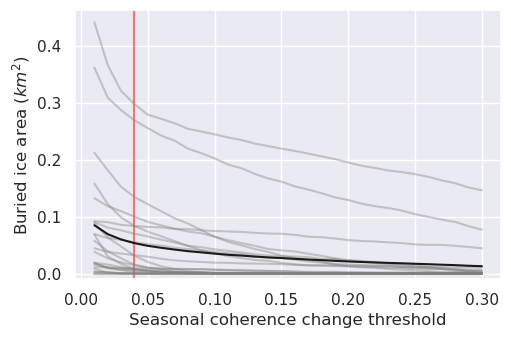

In [190]:
f, ax = plt.subplots(figsize=(5.5, 3.5))
ax.axvline(0.04, c='red', alpha=0.5)
for i, row in md_df.iterrows():
    dam_df = df[df['moraine_name'] == row.survey_name.strip()]
    ax.plot(dam_df.threshold, dam_df.buried_ice_area, c='gray', alpha=0.4)
ax.plot(df.groupby('threshold')['buried_ice_area'].mean(), c='k', label='Mean')
#ax.plot(df.groupby('threshold')['buried_ice_area'].median(), c='yellow', label='Mean')
ax.set_xlabel('Seasonal coherence change threshold')
ax.set_ylabel('Buried ice area ($km^2$)')
ax.set_ylim(-0.01)
f.savefig('../figs/buried_ice_area_sensitivity.png', dpi=400, bbox_inches='tight')
#ax.legend()

In [245]:
(df[df.threshold == 0.02].buried_ice_area > 0.00).sum()

21

In [244]:
(df[(df.threshold > 0.05) & (df.threshold < 0.065)].buried_ice_area > 0.00).sum()

18

In [235]:
(df[df.threshold == 0.02].percent_buried_ice.mean() - df[(df.threshold > 0.05) & (df.threshold < 0.065)].percent_buried_ice.mean())/df[df.threshold == 0.04].percent_buried_ice.mean()

0.5522454817921242

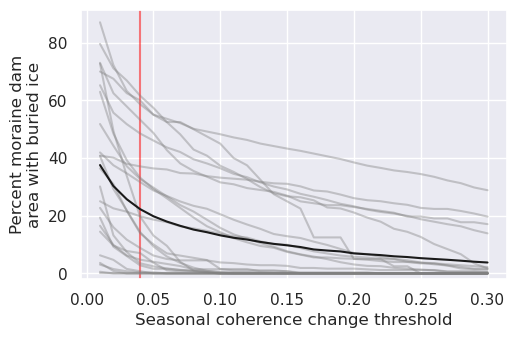

In [192]:
f, ax = plt.subplots(figsize=(5.5, 3.5))
ax.axvline(0.04, c='red', alpha=0.5)
for i, row in md_df.iterrows():
    dam_df = df[df['moraine_name'] == row.survey_name.strip()]
    ax.plot(dam_df.threshold, dam_df.percent_buried_ice, c='gray', alpha=0.4)

ax.plot(df.groupby('threshold')['percent_buried_ice'].mean(), c='k', label='Mean')
ax.set_xlabel('Seasonal coherence change threshold')
ax.set_ylabel('Percent moraine dam\narea with buried ice')
ax.set_ylim(-2)
f.savefig('../figs/buried_ice_proportion_sensitivity.png', dpi=400, bbox_inches='tight')
#ax.legend()

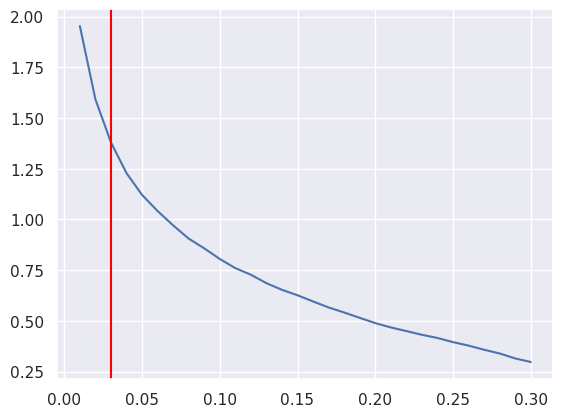

In [131]:
f, ax = plt.subplots()
ax.plot(df.groupby('threshold')['buried_ice_area'].sum())
ax.axvline(0.03, c='red')

In [ ]:
md_area_dic = {}
ice_extent_dic = {}
for i, row in md_df.iterrows():
    print(row.survey_name)
    md_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name}_md.shp')
    md_area_dic[f'{row.survey_name}'] = md_gdf.area.item()
    ice_ds = xr.open_dataset(f'../dams/{row.survey_name}/{row.survey_name.strip()}_ice_map.tif').squeeze()
    ice_extent_dic[f'{row.survey_name.strip()}'] = ice_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs).band_data.sum().item()*400